In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [2]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import optuna
from src.preprocessing import process_dataframe
from src.models.rnn.predict import predict_recursive
from src.evaluation import evaluate
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from src.models.lstm import LSTMRegressor, train_lstm_recursive_val
from src.visualization import plot_forecast, plot_forecast_with_train
from sklearn.metrics import root_mean_squared_error

C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [4]:
df_train_full = process_dataframe(df_train_full)
df_train = process_dataframe(df_train)
df_val = process_dataframe(df_val)
df_test = process_dataframe(df_test)

In [5]:
target_cols = ['48-1 (0)','48-1 (0,5)', '48-1 (1)', '48-1 (1,5)','48-1 (2)', '48-1 (2,5)', '48-1 (3)', 
               '48-1 (3,5)', '48-1 (4)', '48-1 (4,5)', '48-1 (5)', '48-1 (6)', '48-1 (7)', '48-1 (8)', 
               '48-1 (9)', '48-1 (10)']
features_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 
                 'day_of_year_cos', 'is_anomaly']
lags_length = 14

df_train_full = df_train_full[features_cols + target_cols]
df_train = df_train[features_cols + target_cols]
df_val = df_val[features_cols + target_cols]
df_test = df_test[features_cols + target_cols]

In [6]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

train_features_scaled = feature_scaler.fit_transform(df_train[features_cols])
train_target_scaled = target_scaler.fit_transform(df_train[target_cols])

train_scaled = np.hstack((train_features_scaled, train_target_scaled))

val_start = df_train[-lags_length:]
df_full_val = pd.concat([val_start, df_val])

val_features_scaled = feature_scaler.transform(df_full_val[features_cols])
val_target_scaled = target_scaler.transform(df_full_val[target_cols])

val_scaled = np.hstack((val_features_scaled, val_target_scaled))

In [7]:
full_feature_scaler = StandardScaler()
full_target_scaler = StandardScaler()

full_train_features_scaled = full_feature_scaler.fit_transform(df_train_full[features_cols])
full_train_target_scaled = full_target_scaler.fit_transform(df_train_full[target_cols])

full_train_scaled = np.hstack((full_train_features_scaled, full_train_target_scaled))

In [8]:
def create_sequences(data, target_start_index, lags_length):
    X, y = [], []
    for i in range(len(data) - lags_length):
        X.append(data[i : i + lags_length])
        y.append(data[i + lags_length, target_start_index:])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

target_start_index = len(features_cols)

X_train, y_train = create_sequences(train_scaled, target_start_index, lags_length)
X_val, y_val = create_sequences(val_scaled, target_start_index, lags_length)
X_full_train, y_full_train = create_sequences(full_train_scaled, target_start_index, lags_length)

In [9]:
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
full_train_loader = DataLoader(TensorDataset(X_full_train, y_full_train), batch_size=batch_size)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [175]:
val_future_features_tensor = torch.tensor(
    val_scaled[lags_length:, :len(features_cols)], 
    dtype=torch.float32
).to(device)

input_size = train_scaled.shape[1]
output_size = len(target_cols)
criterion = nn.MSELoss()

def objective(trial):
    hidden_size = trial.suggest_int('hidden_size', 16, 112, step=16)
    num_layers = trial.suggest_int('num_layers', 1, 3)
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    
    model_trial = LSTMRegressor(input_size, hidden_size, num_layers, output_size=output_size).to(device)
    optimizer_trial = torch.optim.Adam(model_trial.parameters(), lr=lr)

    model_trial, val_hist = train_lstm_recursive_val(
        model=model_trial,
        criterion=criterion,
        optimizer=optimizer_trial,
        train_loader=train_loader,
        val_loader=val_loader,
        val_future_features=val_future_features_tensor,
        device=device,
        epochs=50,
        max_epochs_no_improvement=10,
        verbose=False
    )
    
    trial.set_user_attr('total_epochs', len(val_hist) - 1)

    best_val_rmse = min(val_hist)
    return best_val_rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("Лучшие параметры: ", study.best_params)
print("Количество эпох в лучшем запуске: ", study.best_trial.user_attrs['total_epochs'])

[I 2026-06-03 16:22:02,363] A new study created in memory with name: no-name-145a3be1-27ce-4ac4-9913-5aa8d3656ea3
[I 2026-06-03 16:22:12,194] Trial 0 finished with value: 0.23085999488830566 and parameters: {'hidden_size': 96, 'num_layers': 2, 'lr': 0.002964693954745403}. Best is trial 0 with value: 0.23085999488830566.


Early stopping on 32 epoch


[I 2026-06-03 16:22:28,047] Trial 1 finished with value: 0.2991349697113037 and parameters: {'hidden_size': 96, 'num_layers': 3, 'lr': 0.009378784117710062}. Best is trial 0 with value: 0.23085999488830566.


Early stopping on 31 epoch


[I 2026-06-03 16:22:42,099] Trial 2 finished with value: 0.37161216139793396 and parameters: {'hidden_size': 112, 'num_layers': 3, 'lr': 0.008311627036533946}. Best is trial 0 with value: 0.23085999488830566.


...

Early stopping on 23 epoch


[I 2026-06-03 16:23:34,087] Trial 8 finished with value: 0.8699062466621399 and parameters: {'hidden_size': 32, 'num_layers': 1, 'lr': 9.413429833385243e-05}. Best is trial 6 with value: 0.20510566234588623.


Early stopping on 24 epoch


[I 2026-06-03 16:23:41,667] Trial 9 finished with value: 0.22750648856163025 and parameters: {'hidden_size': 64, 'num_layers': 2, 'lr': 0.002611243036006597}. Best is trial 6 with value: 0.20510566234588623.


Early stopping on 26 epoch
Лучшие параметры:  {'hidden_size': 64, 'num_layers': 2, 'lr': 0.0017770971146307752}
Количество эпох в лучшем запуске:  25


In [176]:
#input_size = full_train_scaled.shape[1]
model = LSTMRegressor(
    input_size=input_size,
    hidden_size=study.best_params['hidden_size'],
    num_layers=study.best_params['num_layers'],
    output_size=output_size
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=study.best_params['lr'])

model, _ = train_lstm_recursive_val(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    device=device,
    epochs=study.best_trial.user_attrs['total_epochs'],
    max_epochs_no_improvement=10,
    verbose=True
)

Epoch 1/25, Train Loss: 0.6791
Epoch 2/25, Train Loss: 0.1801
Epoch 3/25, Train Loss: 0.1431
Epoch 4/25, Train Loss: 0.1423
Epoch 5/25, Train Loss: 0.1051
Epoch 6/25, Train Loss: 0.0751
Epoch 7/25, Train Loss: 0.0505
Epoch 8/25, Train Loss: 0.0530
Epoch 9/25, Train Loss: 0.0733
Epoch 10/25, Train Loss: 0.0864
Epoch 11/25, Train Loss: 0.0713
Epoch 12/25, Train Loss: 0.0250
Epoch 13/25, Train Loss: 0.0306
Epoch 14/25, Train Loss: 0.0248
Epoch 15/25, Train Loss: 0.0338
Epoch 16/25, Train Loss: 0.0335
Epoch 17/25, Train Loss: 0.0197
Epoch 18/25, Train Loss: 0.0157
Epoch 19/25, Train Loss: 0.0185
Epoch 20/25, Train Loss: 0.0175
Epoch 21/25, Train Loss: 0.0223
Epoch 22/25, Train Loss: 0.0213
Epoch 23/25, Train Loss: 0.0181
Epoch 24/25, Train Loss: 0.0127
Epoch 25/25, Train Loss: 0.0194


In [10]:
model_path = "models/lstm_v1.pth"
weights_path = "models/lstm_v1_weights.pth"

In [178]:
torch.save(model, model_path)
torch.save(model.state_dict(), weights_path)

In [11]:
model = torch.load(model_path, weights_only=False)

                              RMSE       MAE        ME       NSE
Значение для всех глубин  0.691339  0.535856  0.067033  0.960096


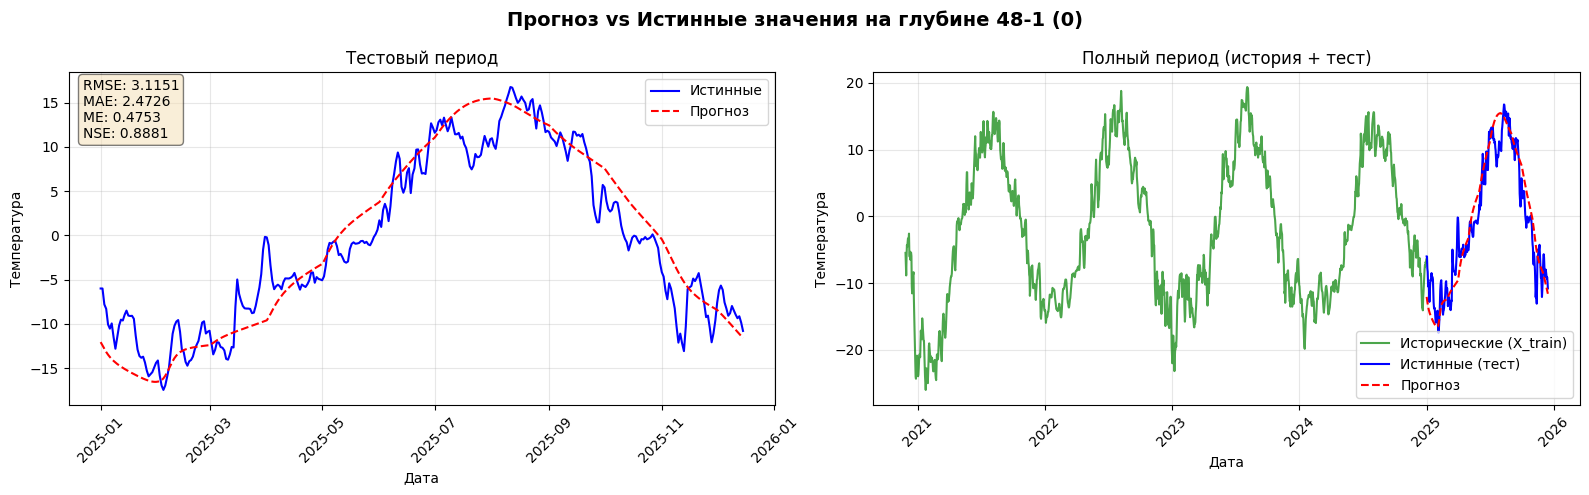

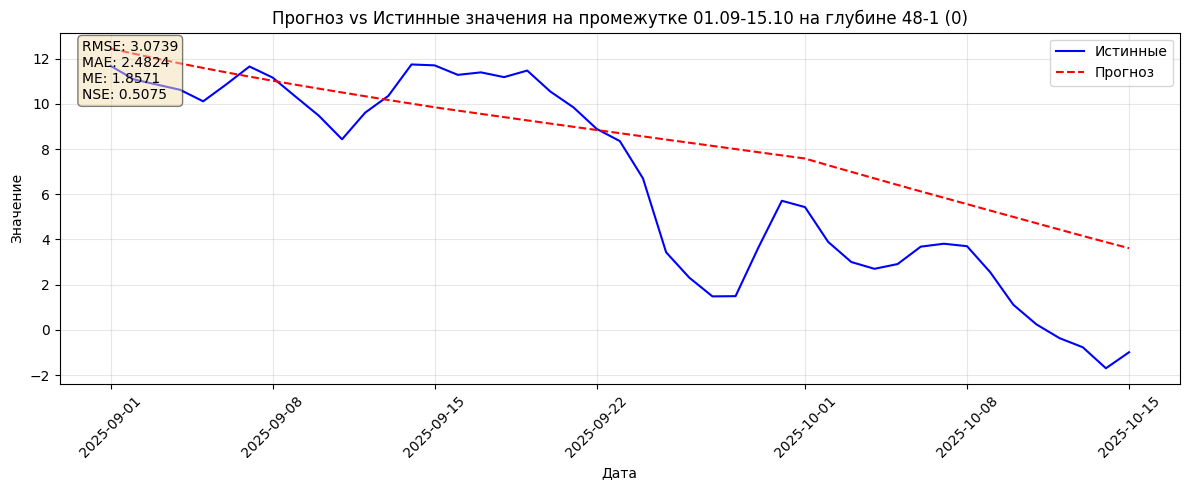

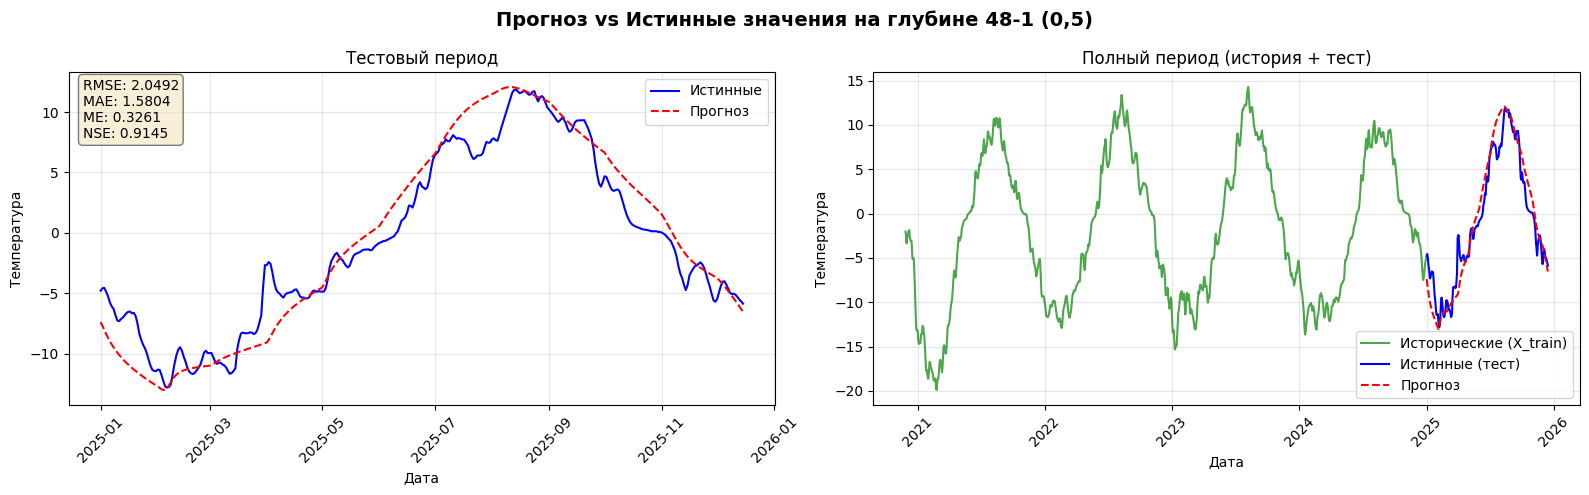

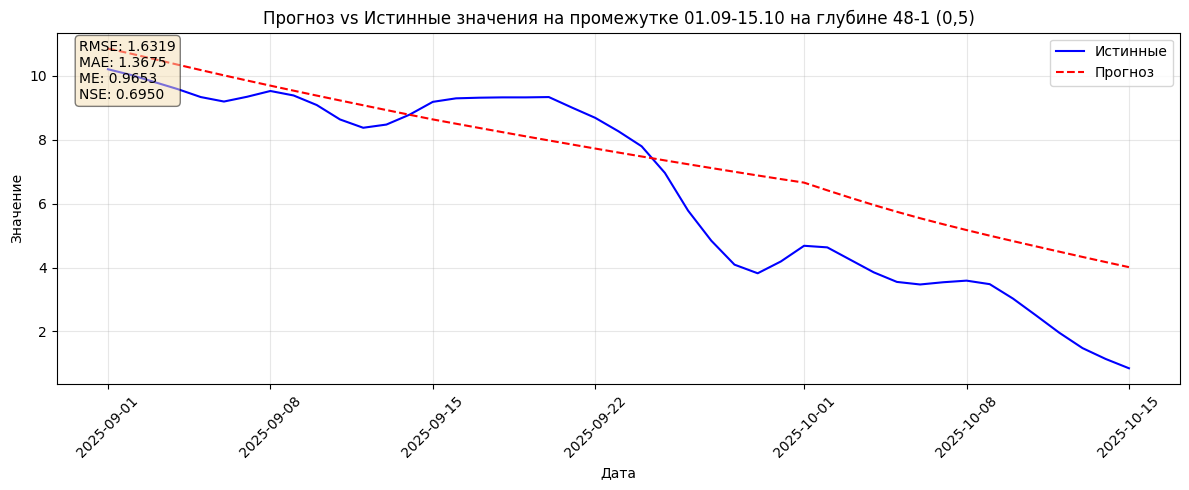

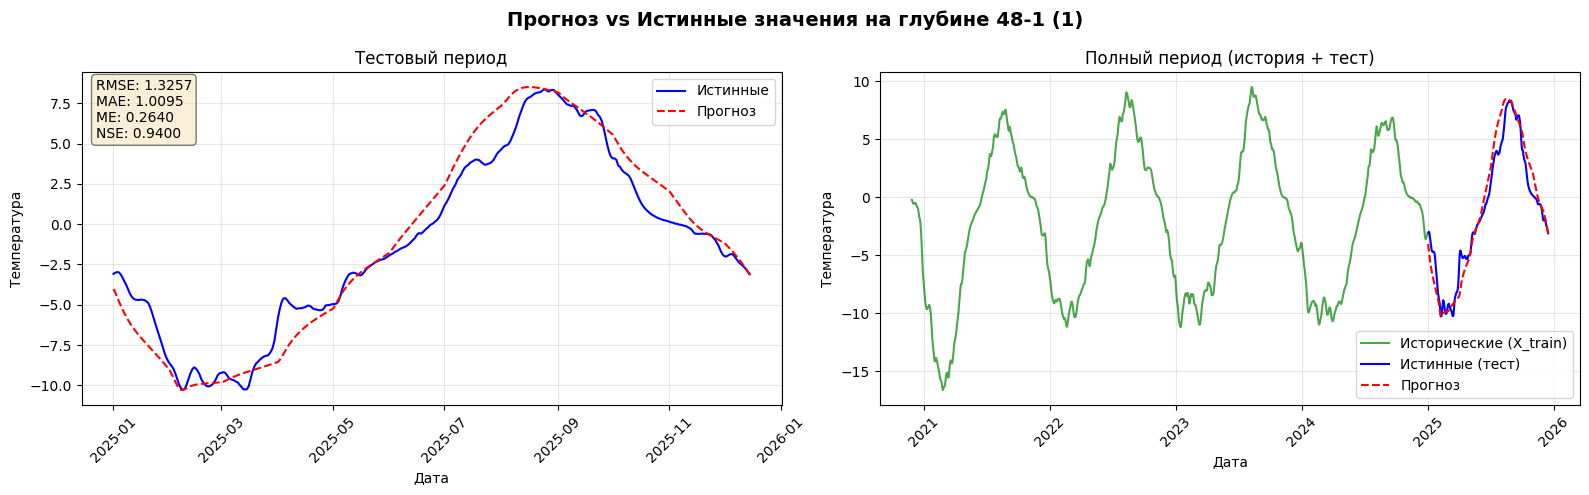

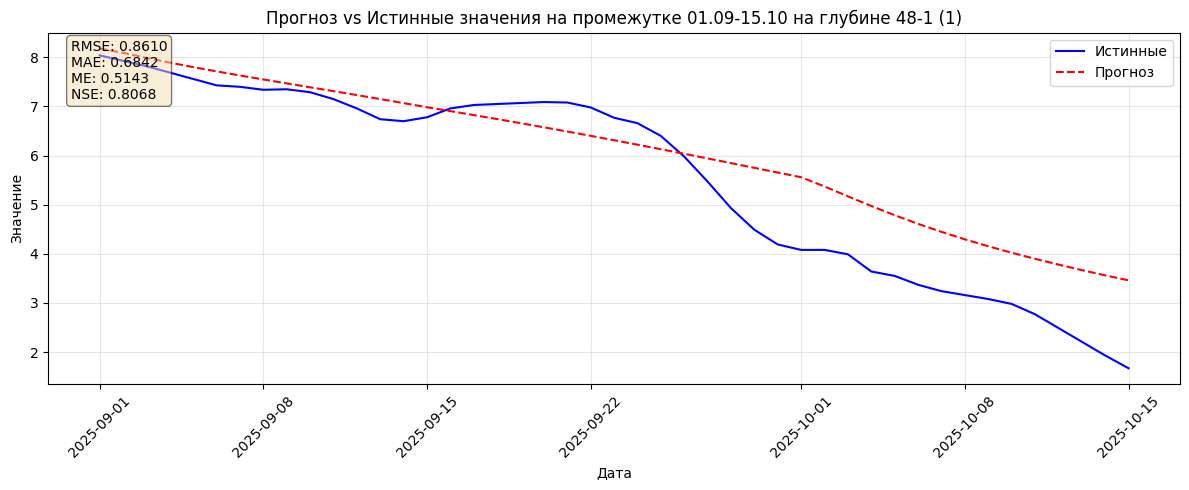

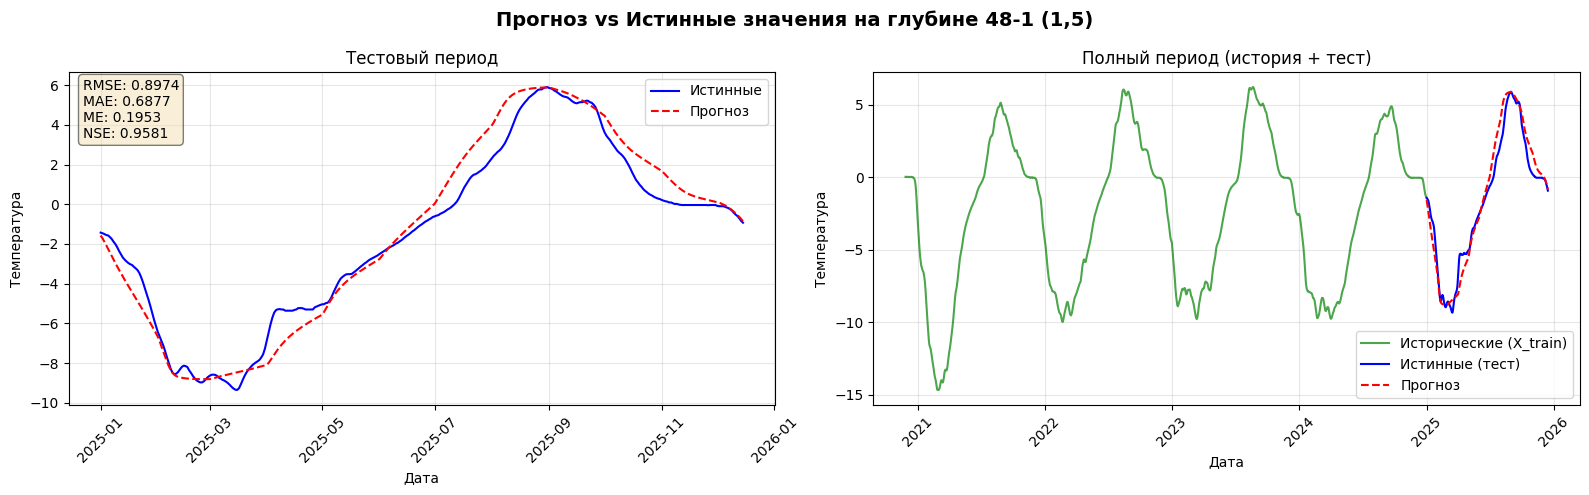

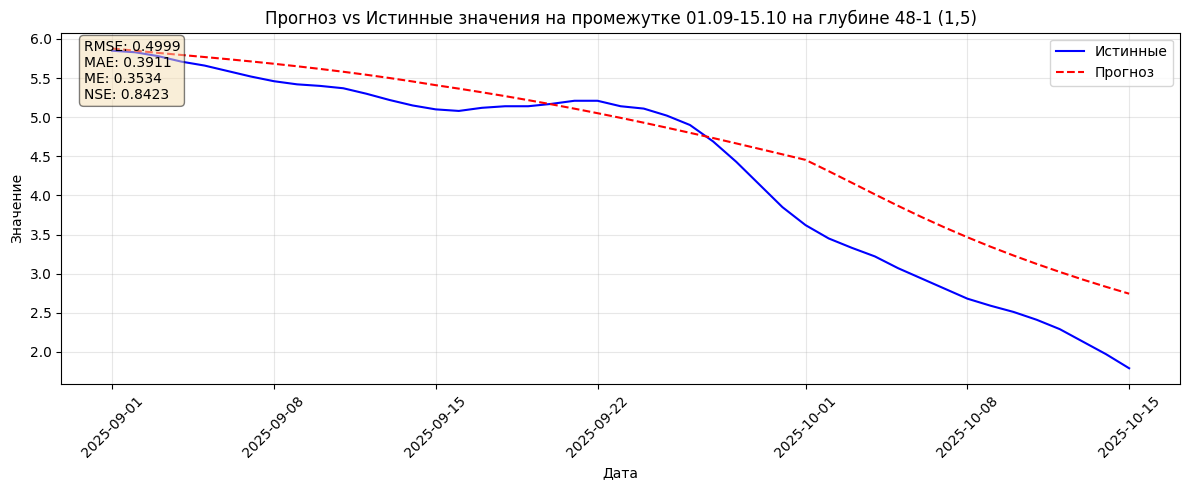

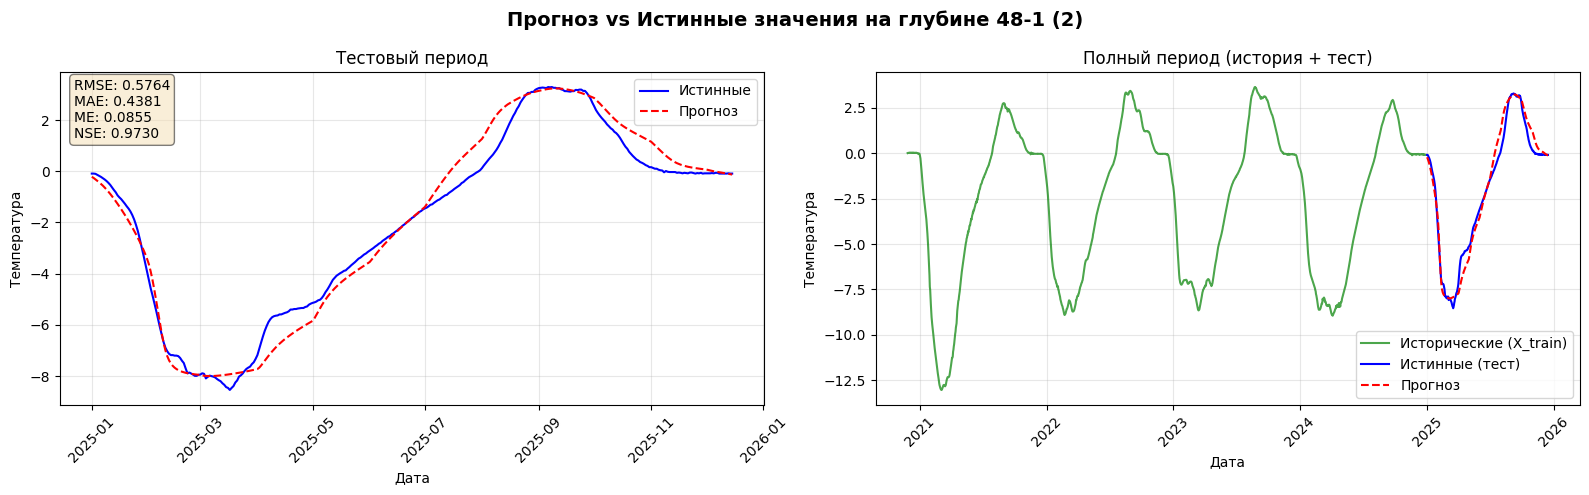

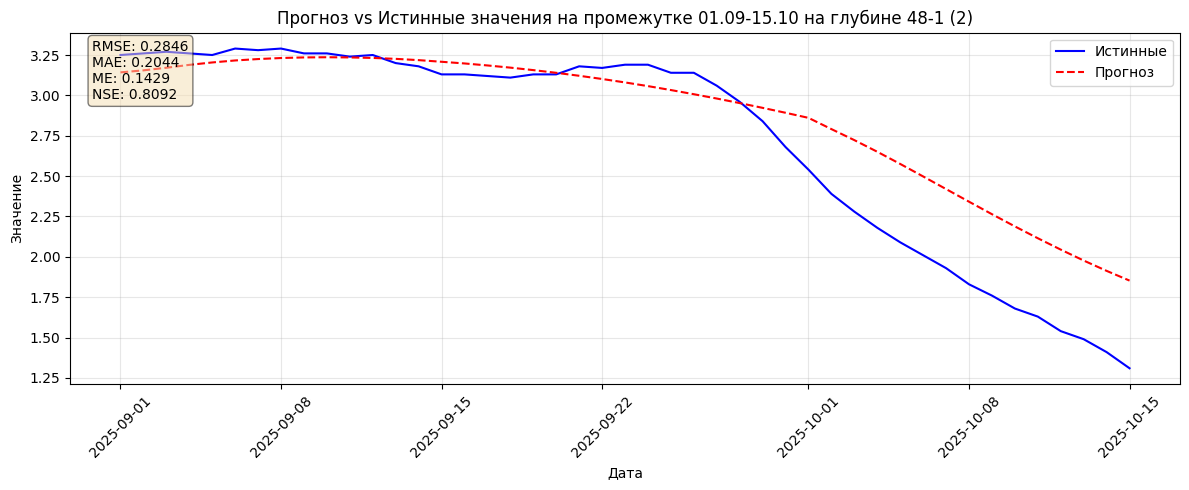

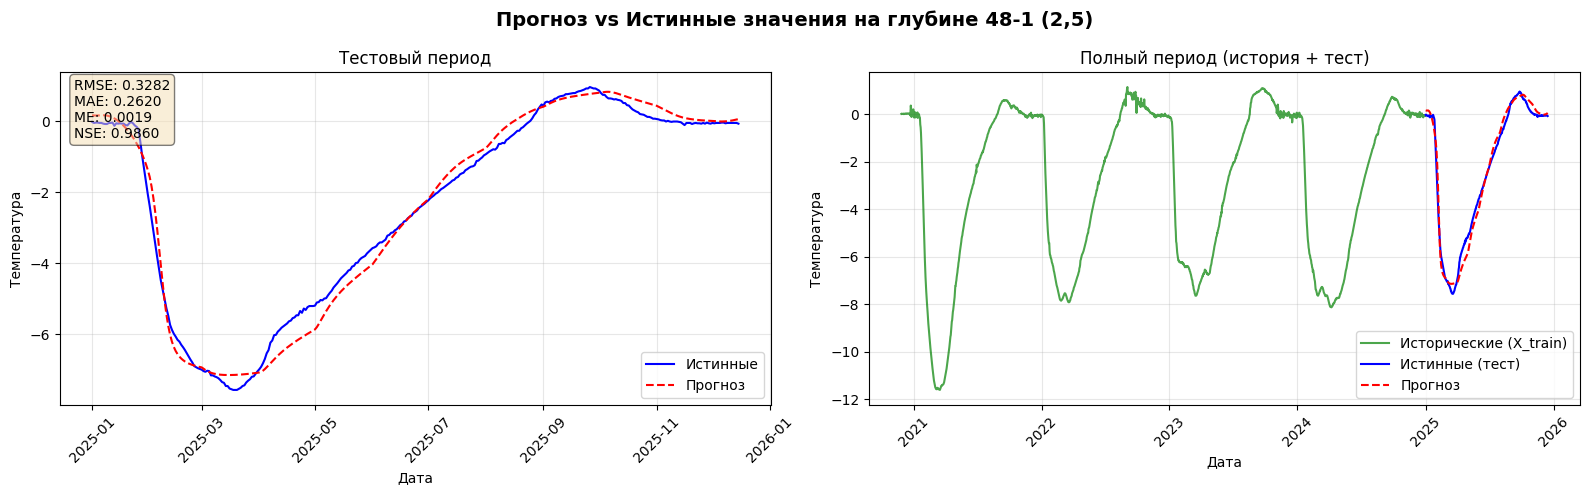

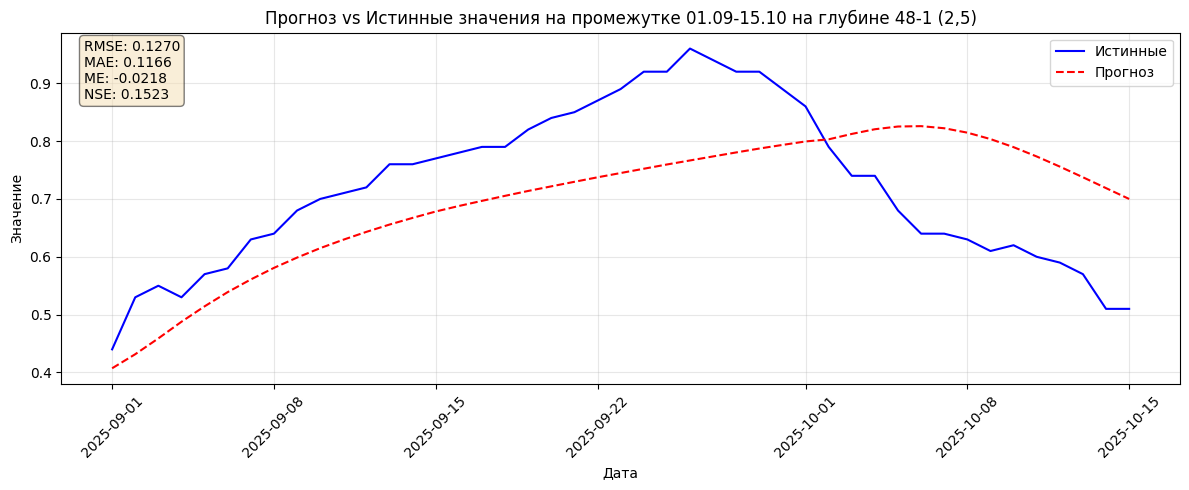

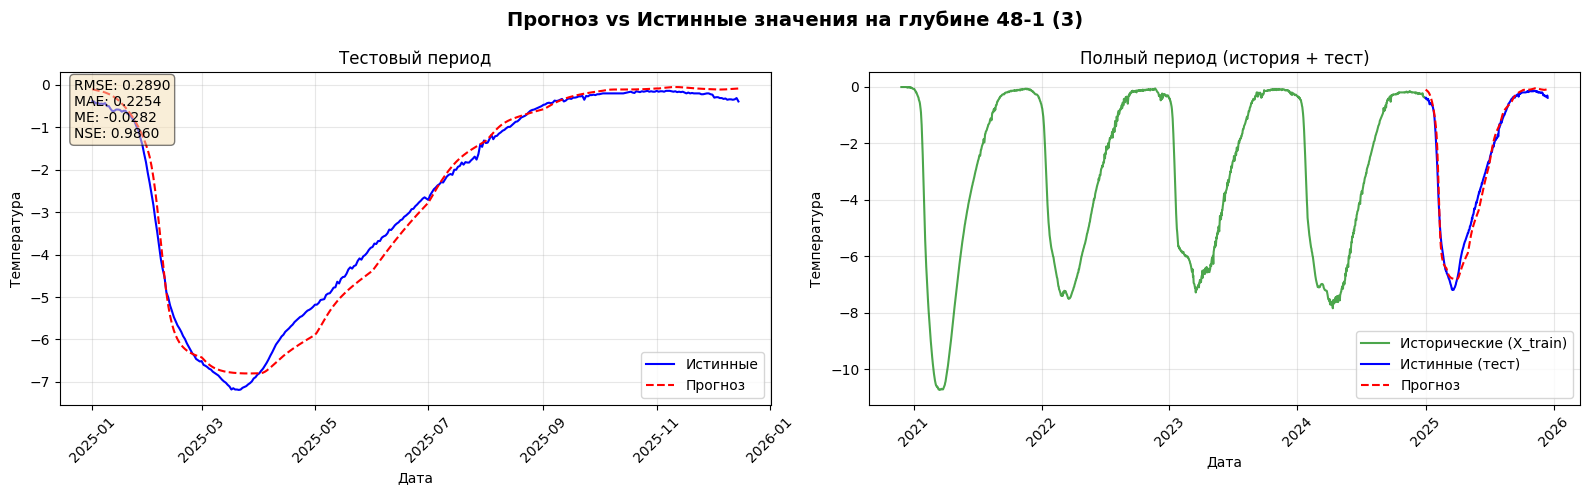

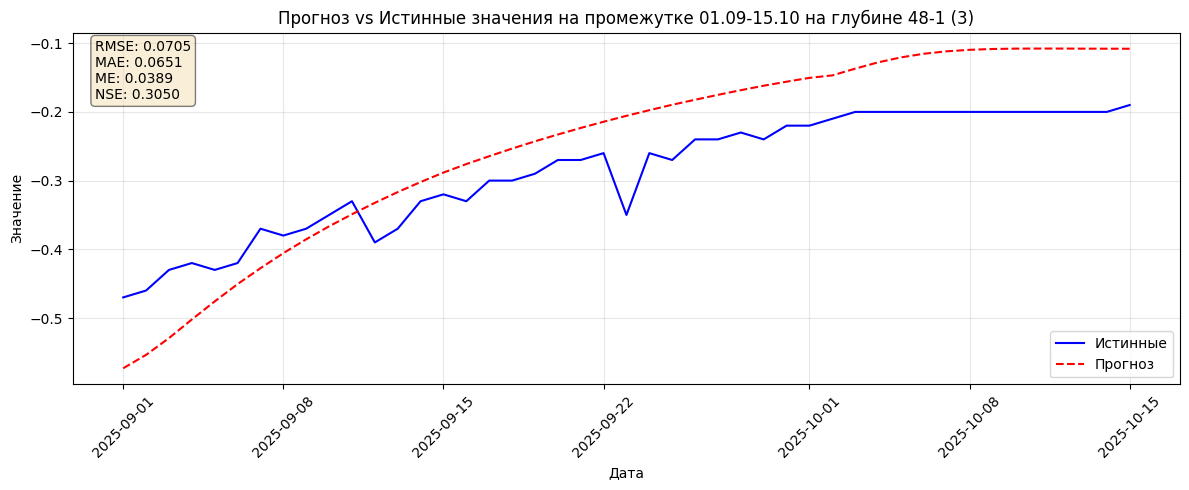

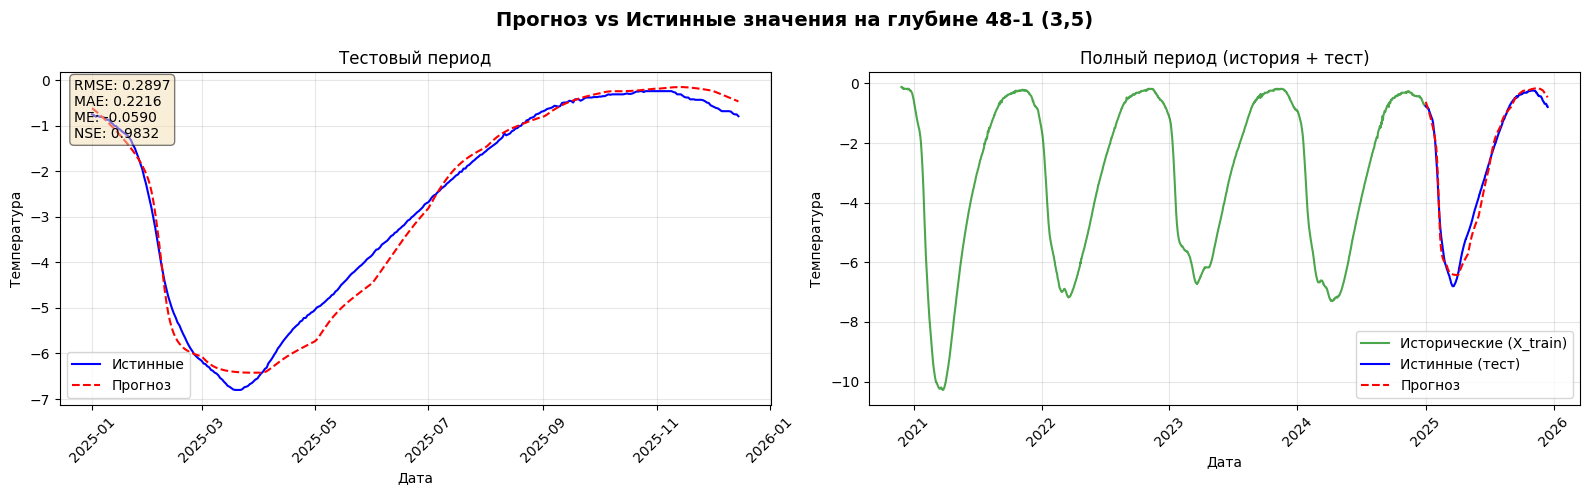

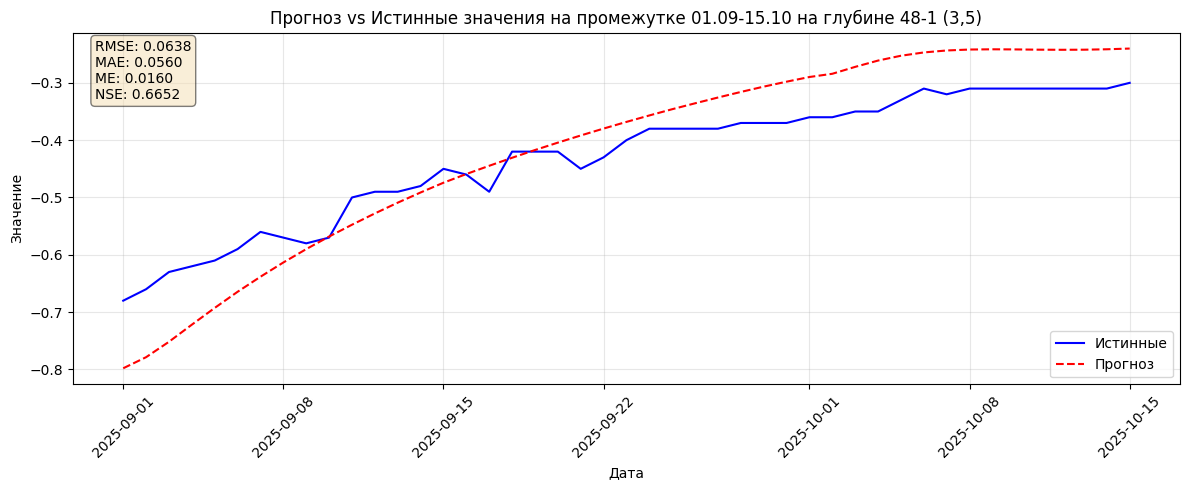

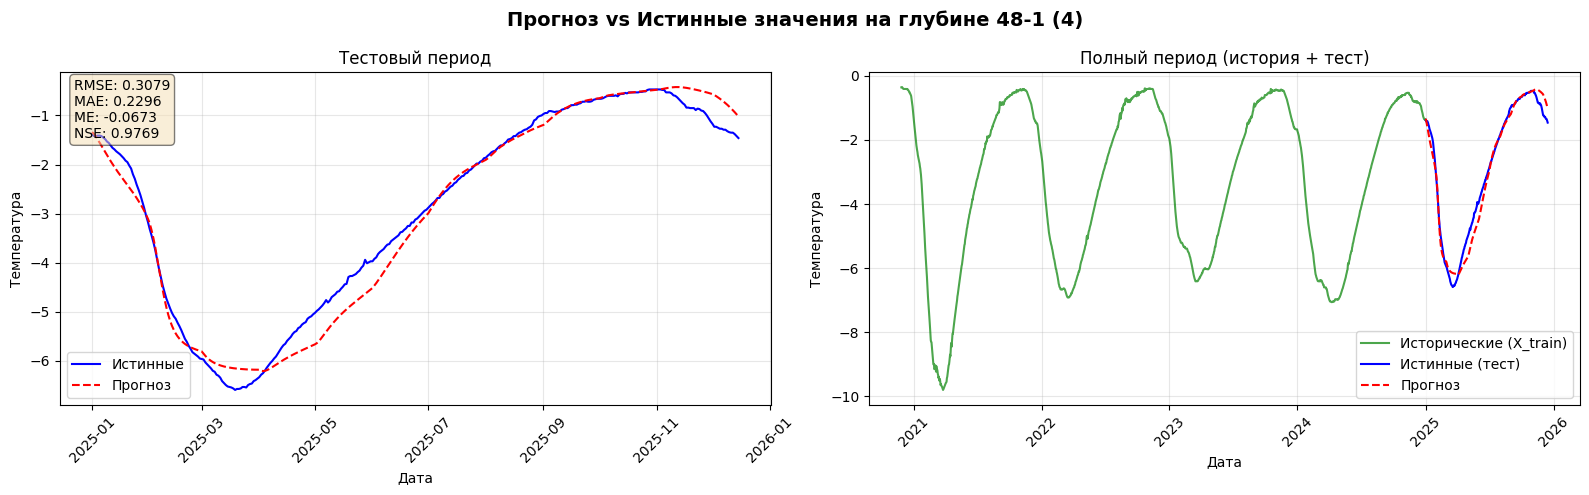

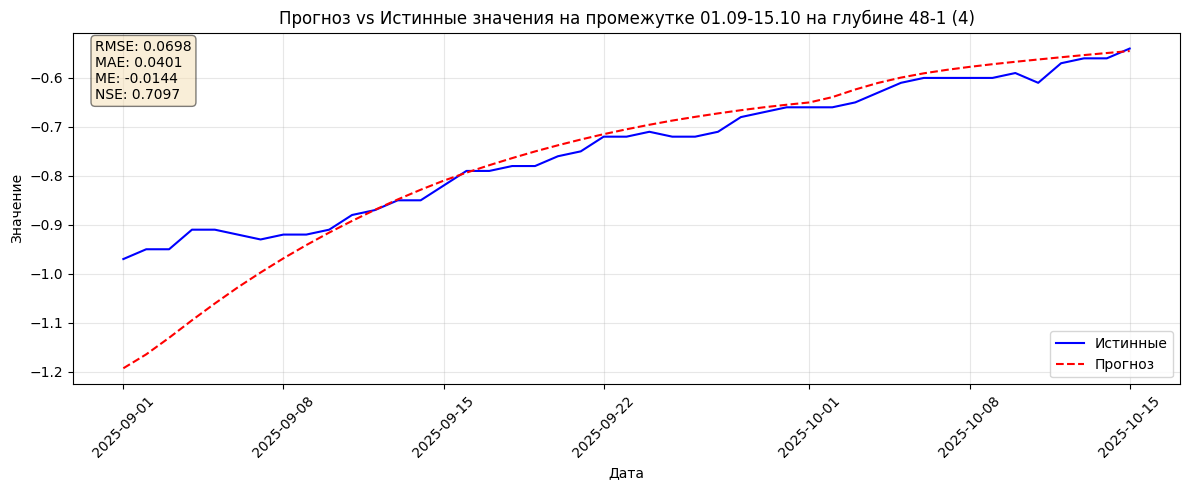

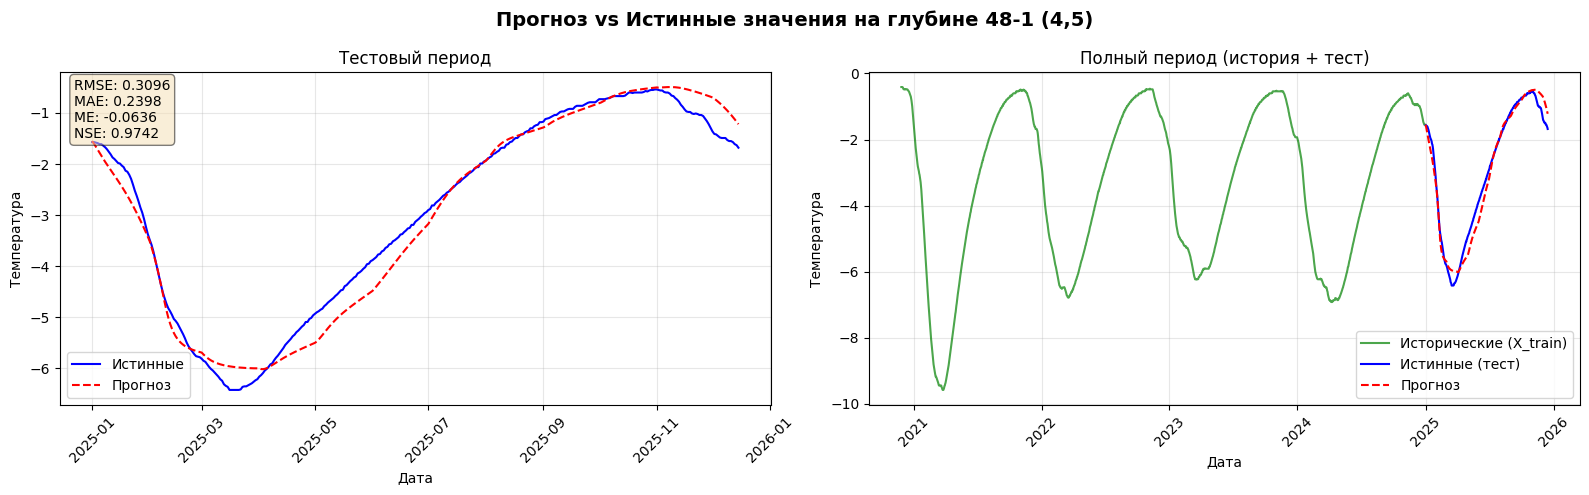

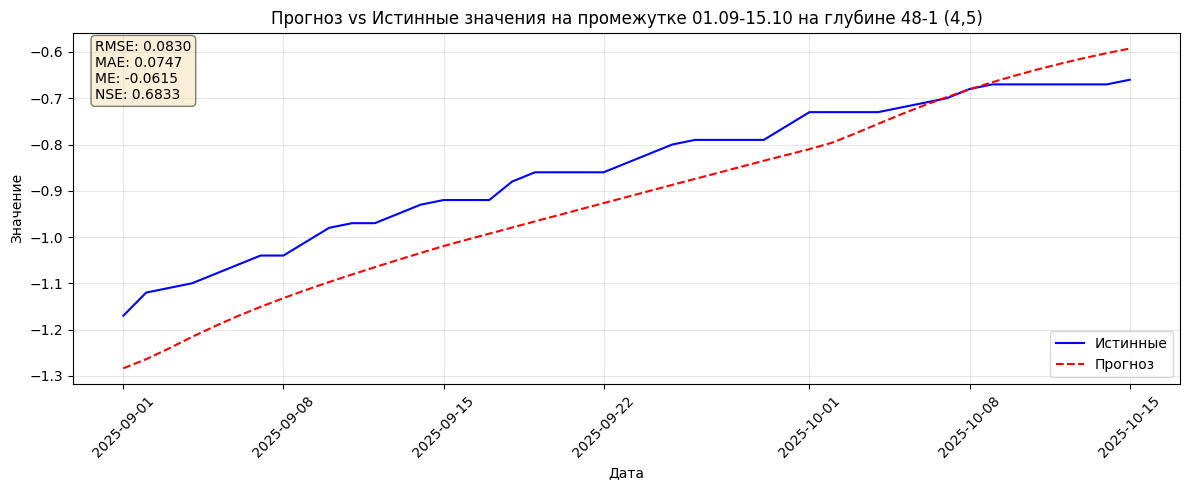

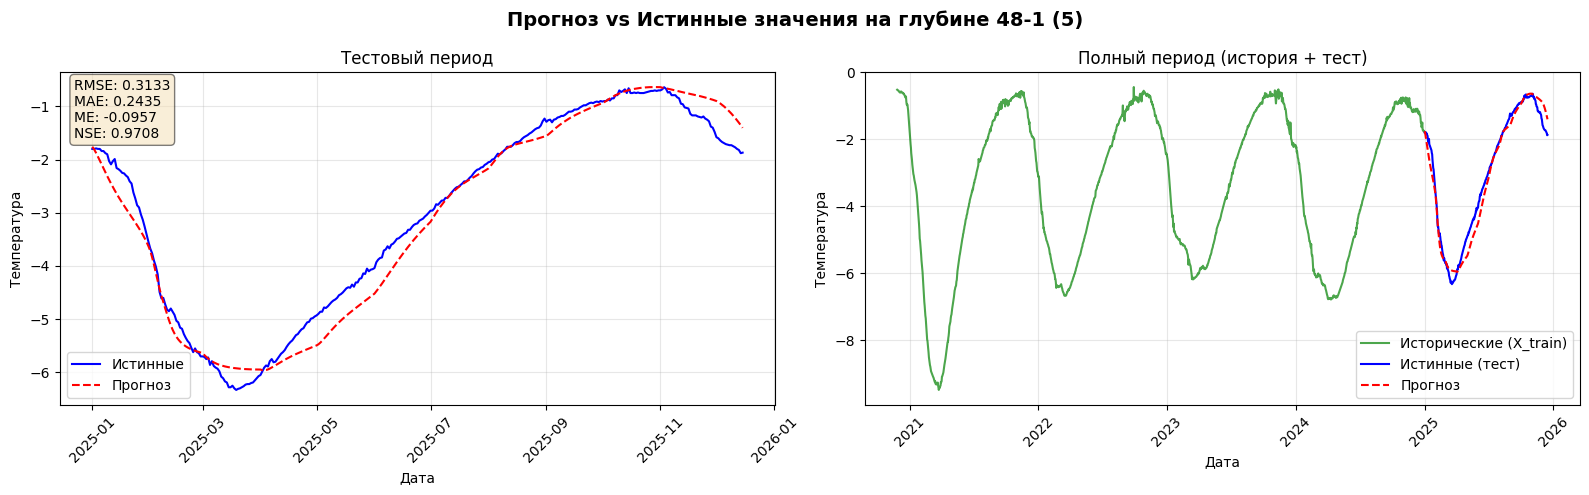

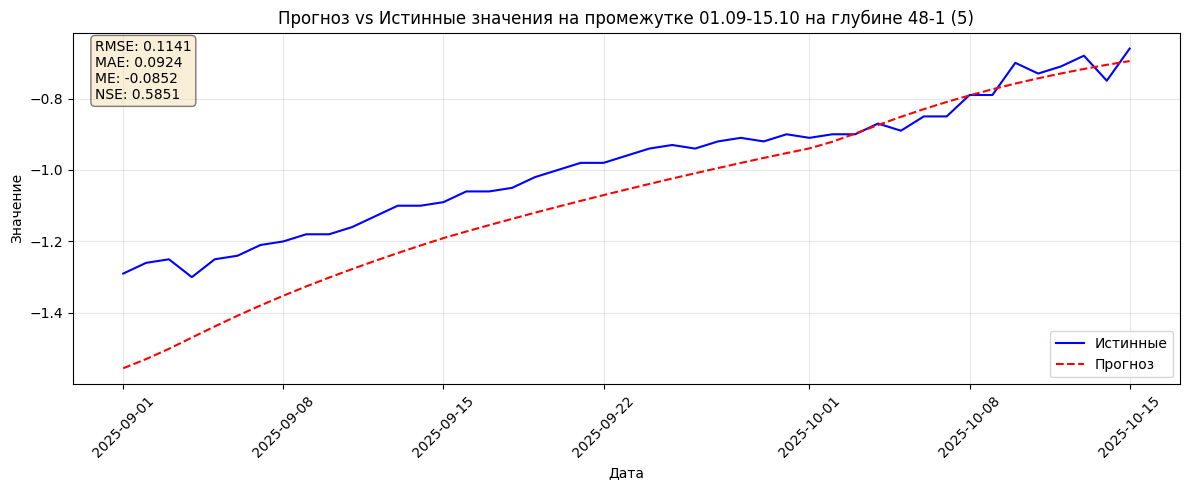

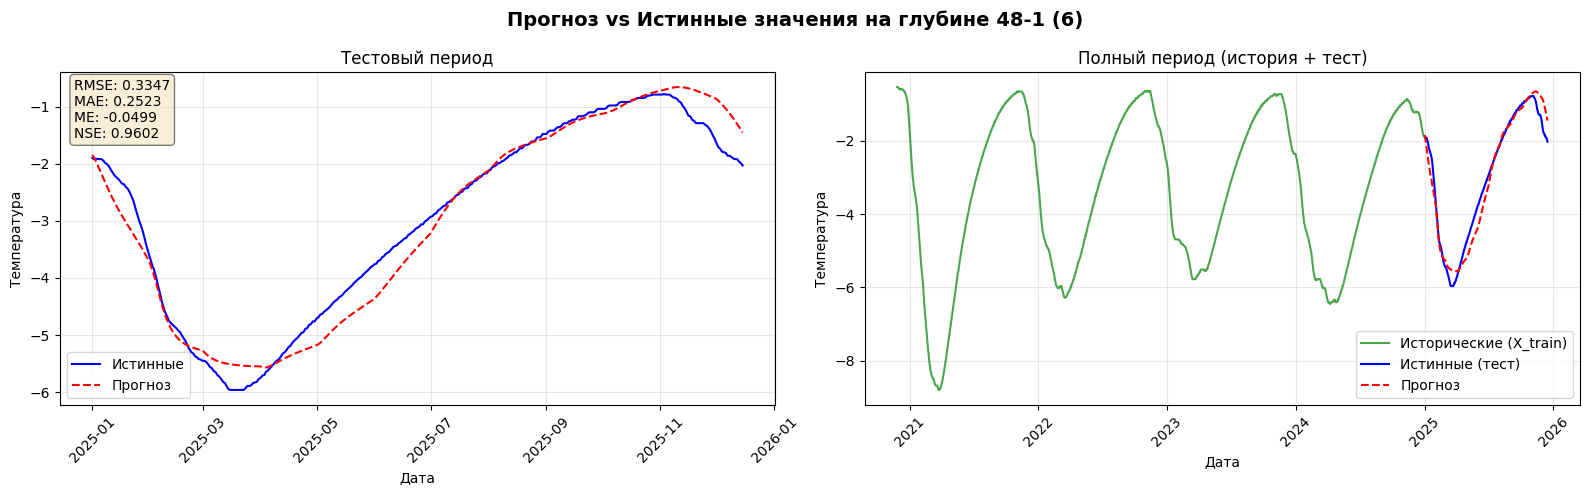

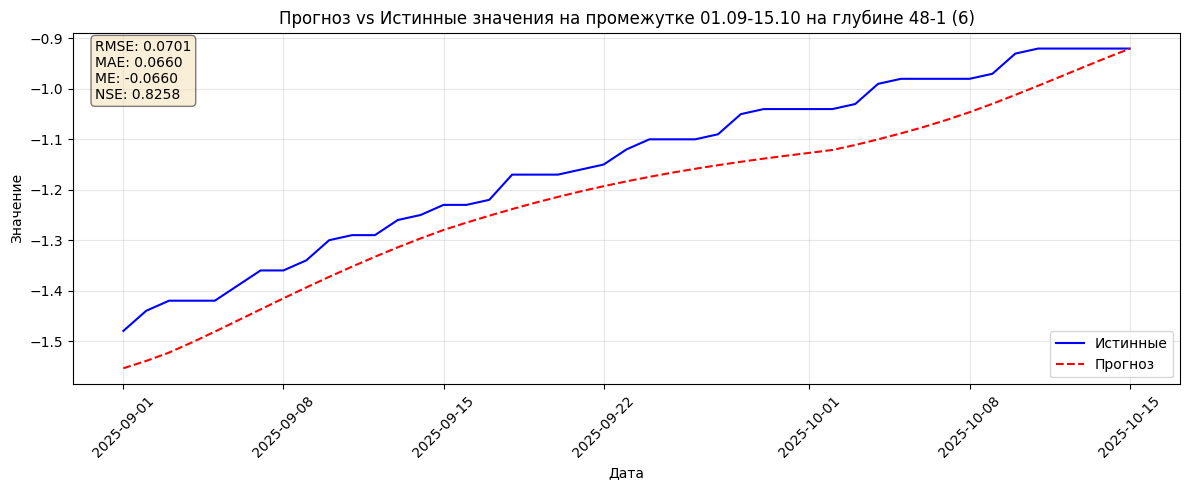

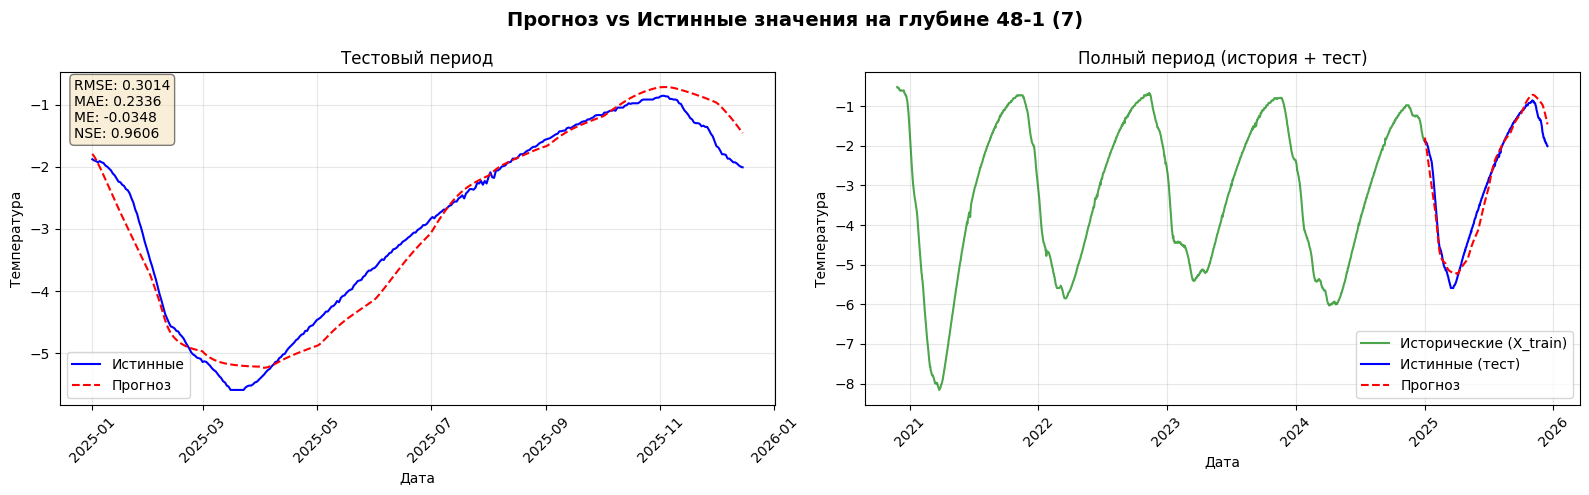

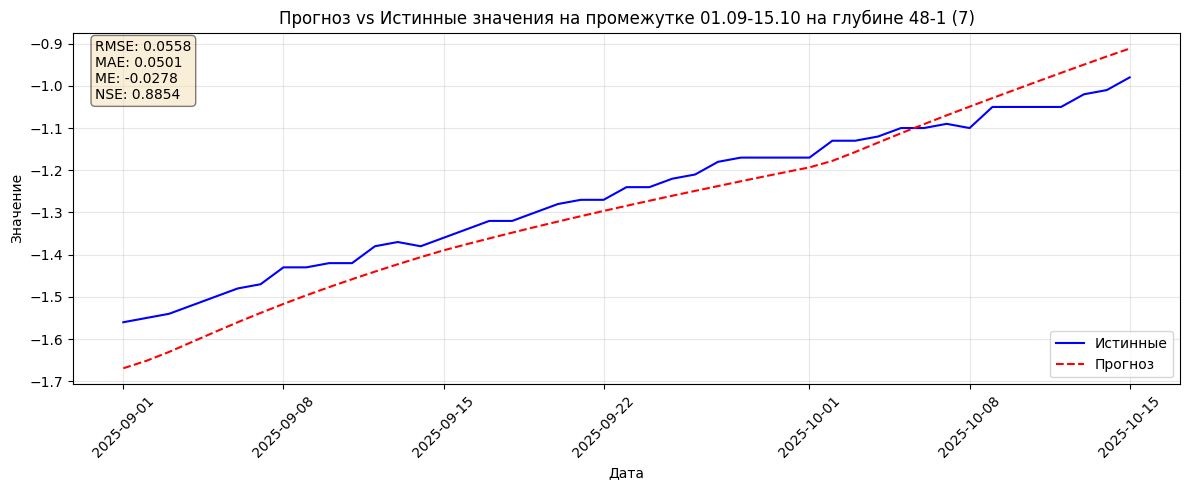

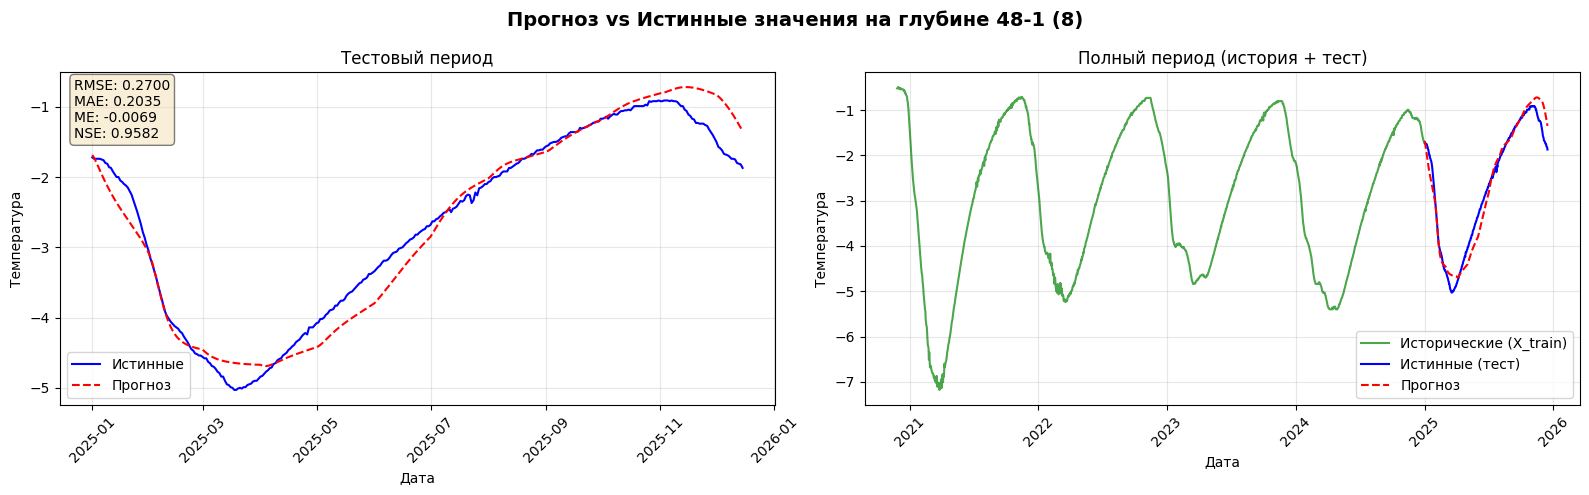

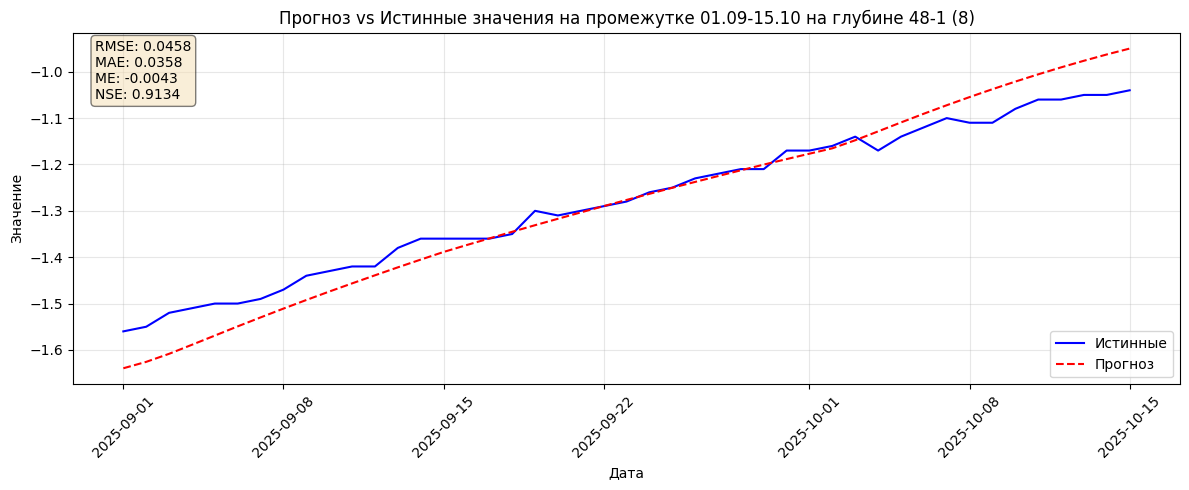

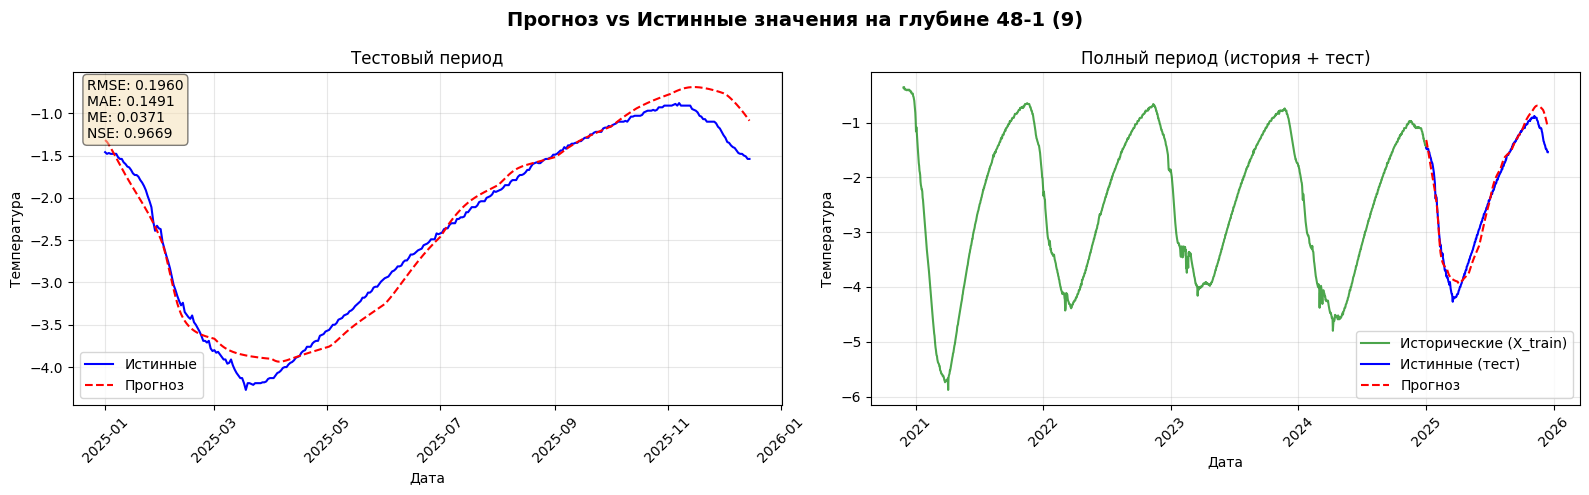

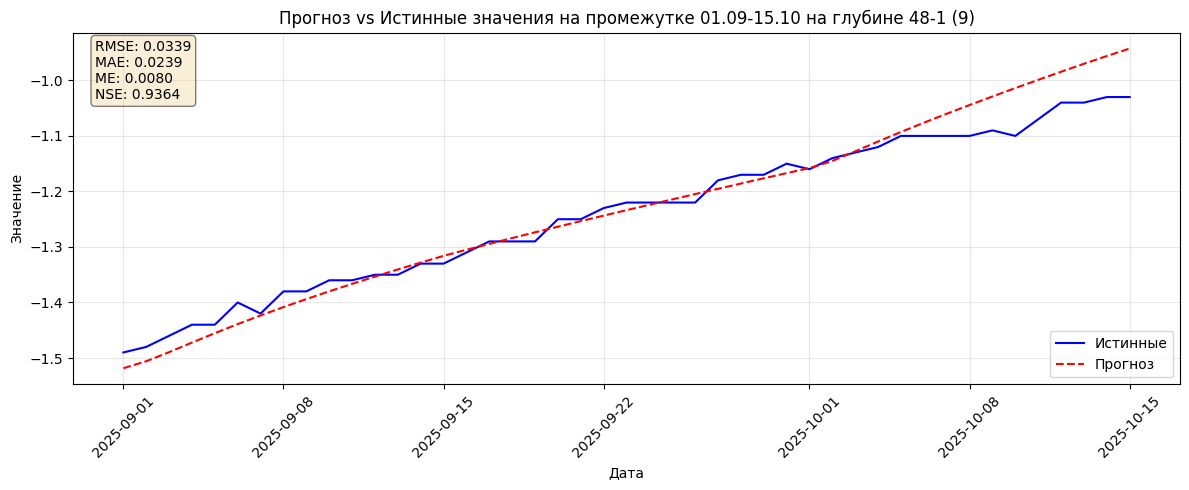

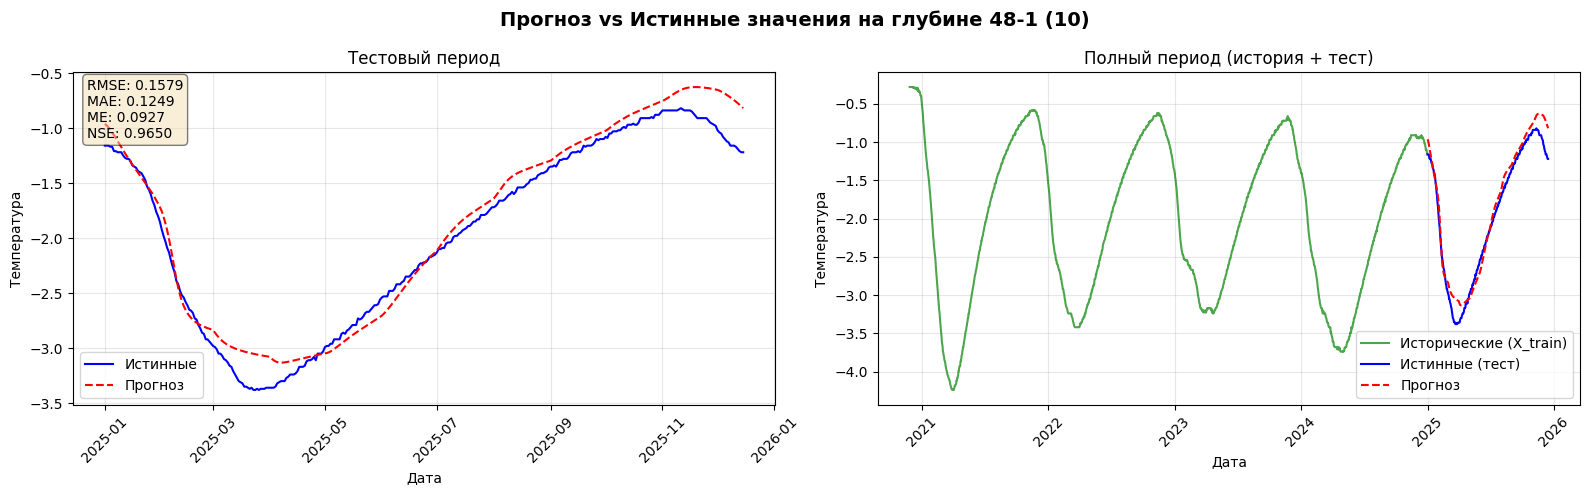

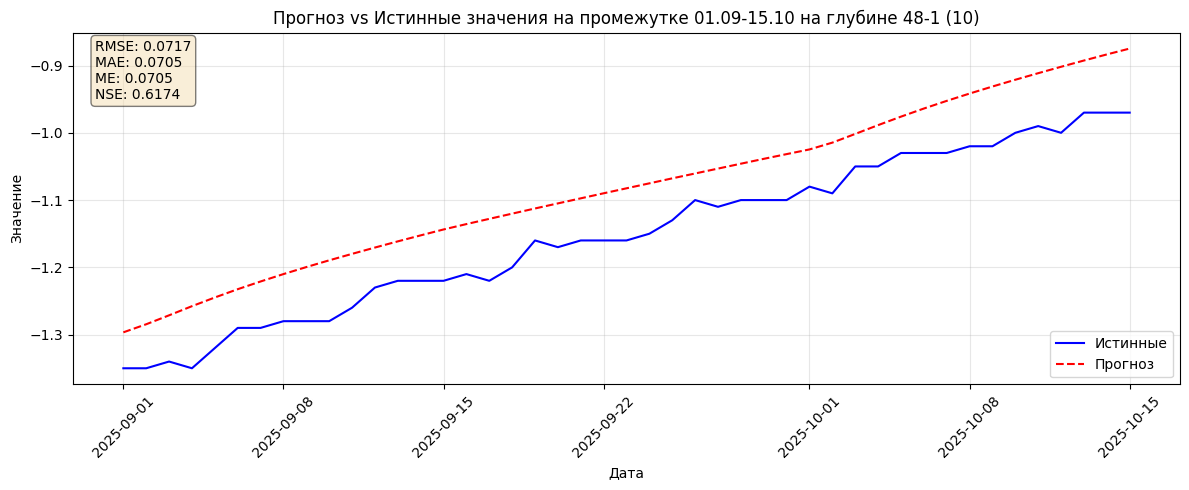

In [14]:
test_start = df_train_full[-lags_length:]

y_pred = predict_recursive(
    model=model,
    df_test=df_test,
    test_start=test_start,
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    features_cols=features_cols,
    target_cols=target_cols,
    device=device
)
y_true = df_test[target_cols].values

eval_dict = evaluate(y_true, y_pred)
print(pd.DataFrame(eval_dict, index=['Значение для всех глубин']))

for i, col in enumerate(target_cols):
    metrics = evaluate(y_true[:, i], y_pred[:, i])
    s_true = pd.Series(y_true[:, i], index=df_test.index)
    s_pred = pd.Series(y_pred[:, i], index=df_test.index)
    
    s_true_autumn = s_true['2025-09-01':'2025-10-15']
    s_pred_autumn = s_pred['2025-09-01':'2025-10-15']
    metrics_autumn = evaluate(s_true_autumn.values, s_pred_autumn.values)
    
    plot_forecast_with_train(df_train_full[col], pd.DataFrame(s_true), pd.DataFrame(s_pred), metrics_dict=metrics, title=f'Прогноз vs Истинные значения на глубине {col}')
    plot_forecast(pd.DataFrame(s_true_autumn), pd.DataFrame(s_pred_autumn), metrics_dict=metrics_autumn, title=f'Прогноз vs Истинные значения на промежутке 01.09-15.10 на глубине {col}')